#Intentado hallar el rango de IDs donde trabaja Scimago

In [1]:
import requests
import time

def explorar_ids_paso_a_paso():
    ids_validos = []
    ids_chilenos = []

    for i in range(40000, 100000, 100):  # De 1 a 10000, paso 100
        url = f"https://www.scimagoiber.com/institution.php?id={i}"

        try:
            response = requests.get(url, timeout=10)

            if response.status_code == 200:
                es_chileno = "(CHL)" in response.text
                ids_validos.append(i)

                if es_chileno:
                    ids_chilenos.append(i)
                    #print(f"ID {i:4d} VÁLIDO - CHILENO")
                else:
                    print(f"ID {i:4d} VÁLIDO - Otro país")
            else:
                print(f"ID {i:4d} INVÁLIDO (Status: {response.status_code})")

        except requests.exceptions.RequestException as e:
            print(f"ID {i:4d}  ERROR: {e}")
            print_gato_error()

        # Pausa para no sobrecargar el servidor
        time.sleep(0.5)

    # Resultados
    print("\n" + "="*60)
    print("RESULTADOS DE LA EXPLORACIÓN:")
    print("="*60)
    print(f"Total IDs probados: {len(range(1, 10001, 100))}")
    print(f"IDs válidos encontrados: {len(ids_validos)}")
    print(f"IDs chilenos encontrados: {len(ids_chilenos)}")

    if ids_validos:
        print(f"\nRango de IDs válidos: {min(ids_validos)} - {max(ids_validos)}")

    if ids_chilenos:
        print(f"IDs chilenos específicos: {sorted(ids_chilenos)}")
        print(f"Rango sugerido para CHL: {min(ids_chilenos)} - {max(ids_chilenos)}")

    return ids_validos, ids_chilenos

# Ejecutar la exploración completa
if __name__ == "__main__":
    print("Iniciando exploración de IDs")
    ids_validos, ids_chilenos = explorar_ids_paso_a_paso()

Iniciando exploración de IDs
ID 40000 VÁLIDO - Otro país
ID 40100 VÁLIDO - Otro país
ID 40200 VÁLIDO - Otro país
ID 40300 VÁLIDO - Otro país
ID 40400 VÁLIDO - Otro país
ID 40500 VÁLIDO - Otro país
ID 40600 VÁLIDO - Otro país
ID 40700 VÁLIDO - Otro país
ID 40800 VÁLIDO - Otro país
ID 40900 VÁLIDO - Otro país


KeyboardInterrupt: 

#Haciendo scrapping de los datos

In [ ]:
import requests
from bs4 import BeautifulSoup
import re
import csv

# Lista para almacenar todos los datos
todos_los_datos = []

# Rango de IDs
for i in range(1100, 1300):
    url = f"https://www.scimagoiber.com/institution.php?id={i}"
    response = requests.get(url)

    if response.status_code == 200:
        html_source = response.text

        # Verificar si la página contiene (CHL) en el HTML
        if "(CHL)" not in html_source:
            continue

        # Extraer el nombre de la institución
        soup = BeautifulSoup(html_source, 'html.parser')
        h1_tag = soup.find('h1')

        nombre_institucion = "Nombre no encontrado"
        if h1_tag:
            nombre_institucion = h1_tag.get_text(strip=True)
        else:
            h1_match = re.search(r'<h1>(.*?)</h1>', html_source)
            if h1_match:
                nombre_institucion = h1_match.group(1).strip()

        # Buscar la línea con var data=
        datos_encontrados = False
        for line in html_source.splitlines():
            if line.startswith("var data=") and "years;idp;lang;excel_lider;" in line:
                # Extraer el contenido entre comillas
                raw_data = line.split('"', 1)[1].rsplit('"', 1)[0]

                # Separar filas
                rows = raw_data.strip().split("\\n")

                # Separar columnas
                table = [r.split(";") for r in rows]

                # Guardar datos para CSV
                if not todos_los_datos:
                    encabezados = ['ID', 'Institucion'] + table[0]
                    todos_los_datos.append(encabezados)

                # Guardar cada fila de datos
                for row in table[1:]:
                    if row:
                        todos_los_datos.append([str(i), nombre_institucion] + row)

                datos_encontrados = True
                break

        if not datos_encontrados:
            pass

    else:
        pass

# Guardar los datos en CSV
if todos_los_datos:
    with open("instituciones_chilenas.csv", 'w', newline='', encoding='utf-8') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerows(todos_los_datos)

    instituciones_procesadas = len(set([row[0] for row in todos_los_datos[1:]]))
    total_registros = len(todos_los_datos) - 1
    columnas = len(todos_los_datos[0])

    print("EXTRACCION COMPLETADA")
    print("=" * 50)
    print(f"Instituciones procesadas: {instituciones_procesadas}")
    print(f"Registros guardados: {total_registros}")
    print(f"Columnas por registro: {columnas}")
    print(f"Archivo guardado: instituciones_chilenas.csv")
else:
    print("No se encontraron datos para guardar")
    print_gato_error()

## **Eliminar Asteriscos y Comillas**

In [ ]:
import pandas as pd
import os
from google.colab import files

# --- 1. Subir el archivo CSV ---
# Esta función de Colab abre una ventana para que puedas seleccionar tu archivo
print("Por favor, sube tu archivo CSV a continuación:")
uploaded = files.upload()

# Obtener el nombre del archivo subido
# Asumimos que solo subiste un archivo para la limpieza
file_name = list(uploaded.keys())[0]

# --- 2. Cargar el archivo con Pandas ---
try:
    # Intenta leer el archivo. Es buena práctica especificar un delimitador (sep)
    # y encoding, aunque por defecto Pandas suele acertar.
    df = pd.read_csv(file_name, encoding='utf-8')
    print(f"\n✅ Archivo '{file_name}' cargado correctamente.")
    print("Primeras 5 filas ANTES de la limpieza:")
    print(df.head())

except Exception as e:
    print(f"\n❌ ERROR al cargar el archivo: {e}")
    # Finaliza la ejecución si no se puede cargar
    exit()


# --- 3. Definir la función de limpieza y aplicar ---

def limpiar_texto(df):
    """
    Función para eliminar asteriscos (*) y comillas dobles (") de TODAS las columnas
    de texto (tipo 'object', que incluye strings) del DataFrame.
    """

    # Seleccionar solo las columnas de tipo 'object' (cadenas de texto)
    columnas_texto = df.select_dtypes(include=['object']).columns

    # Bucle para aplicar la limpieza en cada columna de texto
    for columna in columnas_texto:
        # La función .str.replace() es muy eficiente en Pandas
        # Usamos regex=False para un reemplazo literal y rápido
        df[columna] = df[columna].str.replace('*', '', regex=False)
        df[columna] = df[columna].str.replace('"', '', regex=False)

    return df

# Aplicar la función de limpieza
df_limpio = limpiar_texto(df.copy()) # Usamos .copy() para no modificar el DF original
print("\n✅ Limpieza de * y \" aplicada a las columnas de texto.")


# --- 4. Guardar y Descargar el nuevo archivo CSV ---

output_file_name = "instituciones_chilenas_limpias.csv"

# Guardar el DataFrame limpio como un nuevo archivo CSV
# index=False evita escribir la columna de índices de Pandas en el CSV
df_limpio.to_csv(output_file_name, index=False, encoding='utf-8')

print(f"\n✅ Archivo limpio guardado como '{output_file_name}'.")
print("Primeras 5 filas DESPUÉS de la limpieza:")
print(df_limpio.head())

# Descargar el archivo para que lo tengas en tu computadora
files.download(output_file_name)
print(f"\n⬇️ '{output_file_name}' ha sido descargado.")

#Ponderaciones de Scimago

In [ ]:
import pandas as pd
import numpy as np

def procesar_y_crear_nuevo_csv():
    # Definir los pesos actualizados
    PESOS = {
        "normalized_impact": 0.13,           # Normalized Impact (NI)
        "excel_lider": 0.08,                # Excellence with Leadership (EwL)
        "output": 0.08,                     # Output (O)
        "lider": 0.05,                      # Scientific Leadership (SL)
        "not_own_journals_output": 0.03,    # Not Own Journals (NotOJ)
        "own_journals": 0.03,               # Own Journals (OJ)
        "excel": 0.02,                      # Excellence (Exc)
        "q1": 0.02,                         # High Quality Publication (Q1)
        "colab": 0.02,                      # International Collaboration (IC)
        "open_access": 0.02,                # Open Access (OA)
        "stp": 0.02,                        # Scientific Talent Pool (STP)
        "ik": 0.10,                         # Innovative Knowledge (IK)
        "patents": 0.10,                    # Patents (PT)
        "tech_impact": 0.10,                # Technological Impact (TI)
        "plumx": 0.03,                      # Altmetrics (AM) - será reemplazado
        "sdg": 0.05,                        # Sustainable Development Goals (SDG)
        "female_stp": 0.03,                 # Female Scientific Talent Pool (FemSTP)
        "overton": 0.03                     # Impact in public policy (OV)
    }

    try:
        # Leer el CSV original
        df = pd.read_csv('instituciones_chilenas_limpias.csv')

        # Calcular Altmetrics (AM) como combinación de plumx y mendeley
        if 'plumx' in df.columns and 'mendeley' in df.columns:
            df['AM'] = df['plumx'] * 0.7 + df['mendeley'] * 0.3
        elif 'plumx' in df.columns:
            df['AM'] = df['plumx']
        elif 'mendeley' in df.columns:
            df['AM'] = df['mendeley']
        else:
            df['AM'] = 0

        # Eliminar columnas mendeley y plumx
        columnas_a_eliminar = ['mendeley', 'plumx']
        for col in columnas_a_eliminar:
            if col in df.columns:
                df = df.drop(col, axis=1)

        # Actualizar el peso para usar AM en lugar de plumx
        PESOS_ACTUALIZADOS = PESOS.copy()
        if 'plumx' in PESOS_ACTUALIZADOS:
            PESOS_ACTUALIZADOS['AM'] = PESOS_ACTUALIZADOS.pop('plumx')

        # Convertir columnas numéricas y rellenar NaN con 0
        for columna in PESOS_ACTUALIZADOS.keys():
            if columna in df.columns:
                df[columna] = pd.to_numeric(df[columna], errors='coerce').fillna(0)

        # Filtrar por año 2023 si existe la columna years
        if 'years' in df.columns:
            año_deseado = 2023
            if año_deseado in df['years'].unique():
                df = df[df['years'] == año_deseado].copy()
            else:
                ultimo_anio = df['years'].max()
                df = df[df['years'] == ultimo_anio].copy()

        # Calcular puntuación ponderada para cada registro
        df['Puntuacion_Total'] = 0
        for columna, peso in PESOS_ACTUALIZADOS.items():
            if columna in df.columns:
                df['Puntuacion_Total'] += df[columna] * peso

        # NORMALIZAR LA PUNTUACIÓN FINAL también (opcional pero recomendado)
        # Esto asegura que las puntuaciones estén en una escala interpretable
        df['Puntuacion_Total'] = (df['Puntuacion_Total'] - df['Puntuacion_Total'].min()) / \
                                (df['Puntuacion_Total'].max() - df['Puntuacion_Total'].min()) * 100

        # Calcular ranking por institución
        if 'Institucion' in df.columns:
            # Calcular el promedio de puntuación por institución
            ranking_promedio = df.groupby('Institucion')['Puntuacion_Total'].mean().reset_index()
            ranking_promedio = ranking_promedio.sort_values('Puntuacion_Total', ascending=False)
            ranking_promedio['Ranking'] = range(1, len(ranking_promedio) + 1)

            # Mapear el ranking de vuelta al DataFrame original
            ranking_dict = ranking_promedio.set_index('Institucion')['Ranking'].to_dict()
            df['Ranking'] = df['Institucion'].map(ranking_dict)

        # ORDENAR EL DATAFRAME POR RANKING (de menor a mayor número = mejor posición)
        df = df.sort_values('Ranking', ascending=True).reset_index(drop=True)

        # Reorganizar columnas para que las más importantes estén primero
        columnas_ordenadas = ['Ranking', 'Institucion', 'Puntuacion_Total'] + \
                            [col for col in df.columns if col not in ['Ranking', 'Institucion', 'Puntuacion_Total']]
        df = df[columnas_ordenadas]

        # Crear nuevo CSV con los cambios
        nuevo_nombre = "instituciones_chilenas_limpias_con_ranking_y_AM.csv"
        df.to_csv(nuevo_nombre, index=False, encoding='utf-8')

        # NORMALIZACIÓN CRÍTICA: Escalar todas las variables a la misma escala (0-100)
        print("Aplicando normalización min-max (0-100)...")
        for columna in PESOS_ACTUALIZADOS.keys():
            if columna in df.columns:
                min_val = df[columna].min()
                max_val = df[columna].max()
                if max_val > min_val:  # Evitar división por cero
                    df[columna] = (df[columna] - min_val) / (max_val - min_val) * 100
                else:
                    df[columna] = 0  # Si todos los valores son iguales

        # Crear nuevo CSV con los cambios
        nuevo_nombre = "instituciones_chilenas_limpias_con_ranking_y_AM_NORMALIZADO.csv"
        df.to_csv(nuevo_nombre, index=False, encoding='utf-8')

        print("✅ Proceso completado con normalización")
        print(f"📊 Rango de puntuaciones: {df['Puntuacion_Total'].min():.2f} - {df['Puntuacion_Total'].max():.2f}")
        print(f"🏆 Ranking: 1° {df.iloc[0]['Institucion']} - Último: {df.iloc[-1]['Institucion']} (Posición {df.iloc[-1]['Ranking']})")

        # Mostrar top 5 instituciones
        print("\n🏅 TOP 5 INSTITUCIONES:")
        for i in range(min(5, len(df))):
            institucion = df.iloc[i]['Institucion']
            puntuacion = df.iloc[i]['Puntuacion_Total']
            ranking = df.iloc[i]['Ranking']
            print(f"   {ranking}°. {institucion} - {puntuacion:.2f} puntos")

        return True

    except FileNotFoundError:
        print("Error: Archivo 'instituciones_chilenas_limpias.csv' no encontrado.")
        return False
    except Exception as e:
        print(f"Error: {e}")
        return False

if __name__ == "__main__":
    exito = procesar_y_crear_nuevo_csv()
    if exito:
        print("Archivo creado con éxito con datos normalizados y ordenado por Ranking")

# Muestreo de los datos



In [ ]:
import pandas as pd

# 1. Carga el archivo CSV en un DataFrame
df = pd.read_csv('instituciones_chilenas_limpias_con_ranking_y_AM.csv')

# 2. Filtra el DataFrame para seleccionar solo las filas con '2014-2018' en la columna 'years'
df_filtrado = df[df['years'] == '2019-2023']

# 3. Redondea todas las columnas numéricas a 2 decimales
df_redondeado = df_filtrado.round(2)

# 4. Aplica un estilo de gradiente de color a las columnas numéricas del DataFrame filtrado
styled_df = df_redondeado.style.background_gradient(cmap='Blues')

# 5. Muestra el DataFrame con el estilo aplicado
styled_df

# Gráficos separados

Imports y configuración general

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os
from scipy import stats

# Crear carpeta para los gráficos
carpeta_graficos = 'graficos_pucv'
os.makedirs(carpeta_graficos, exist_ok=True)

# Configurar estilo de los gráficos
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (12, 8)

# Definir los pesos
PESOS = {
      "normalized_impact": 0.13,           # Normalized Impact (NI)
      "excel_lider": 0.08,                # Excellence with Leadership (EwL)
      "output": 0.08,                     # Output (O)
      "lider": 0.05,                      # Scientific Leadership (SL)
      "not_own_journals_output": 0.03,    # Not Own Journals (NotOJ)
      "own_journals": 0.03,               # Own Journals (OJ)
      "excel": 0.02,                      # Excellence (Exc)
      "q1": 0.02,                         # High Quality Publication (Q1)
      "colab": 0.02,                      # International Collaboration (IC)
      "open_access": 0.02,                # Open Access (OA)
      "stp": 0.02,                        # Scientific Talent Pool (STP)
      "ik": 0.10,                         # Innovative Knowledge (IK)
      "patents": 0.10,                    # Patents (PT)
      "tech_impact": 0.10,                # Technological Impact (TI)
      "AM": 0.03,                         # Altmetrics (AM)
      "sdg": 0.05,                        # Sustainable Development Goals (SDG)
      "female_stp": 0.03,                 # Female Scientific Talent Pool (FemSTP)
      "overton": 0.03                     # Impact in public policy (OV)
}

# Cargar los datos y preparar variables comunes
try:
    df = pd.read_csv('instituciones_chilenas_limpias_con_ranking_y_AM.csv')
    pucv_mask = df['Institucion'].str.contains('Pontificia Universidad Catolica de Valparaiso', case=False, na=False)
    pucv_data = df[pucv_mask]

    if pucv_data.empty:
        raise ValueError("No se encontraron datos para la Pontificia Universidad Catolica de Valparaiso")

    ranking_pucv = pucv_data['Ranking'].iloc[0]
    puntuacion_pucv = pucv_data['Puntuacion_Total'].mean()
    pucv_nombre = pucv_data['Institucion'].iloc[0]

    top_10 = df.groupby('Institucion')['Puntuacion_Total'].mean().nlargest(10)
    top_10_df = df[df['Institucion'].isin(top_10.index)]
    media_top10 = top_10.mean()

    print("✅ Datos cargados y variables preparadas")
except Exception as e:
    print(f"❌ Error al preparar los datos: {e}")

Gráfico de Barras - PUCV vs TOP 10

In [ ]:
# Gráfico 1: Barras - PUCV vs TOP 10
try:
    fig, ax = plt.subplots(figsize=(16, 10))
    top_10_con_pucv = top_10.copy()
    if pucv_nombre not in top_10.index:
        top_10_con_pucv[pucv_nombre] = puntuacion_pucv
        top_10_con_pucv = top_10_con_pucv.nlargest(11)

    comparacion = top_10_con_pucv.reset_index()
    comparacion['Es_PUCV'] = comparacion['Institucion'] == pucv_nombre
    colors = ['red' if es_pucv else 'skyblue' for es_pucv in comparacion['Es_PUCV']]

    bars = ax.barh(comparacion['Institucion'], comparacion['Puntuacion_Total'], color=colors)
    ax.set_xlabel('Puntuación Total', fontweight='bold')
    ax.set_title('PUCV vs TOP 10 INSTITUCIONES', fontsize=16, fontweight='bold')
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)

    for bar in bars:
        width = bar.get_width()
        ax.text(width + 0.5, bar.get_y() + bar.get_height()/2, f'{width:.1f}',
                ha='left', va='center', fontweight='bold')

    plt.tight_layout()
    plt.savefig(f'{carpeta_graficos}/1_pucv_vs_top10.png', dpi=300, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f"❌ Error al generar el Gráfico 1: {e}")

Gráfico de Radar Comparativo

In [ ]:
# Gráfico 2: Radar Comparativo
try:
    variables = [v for v in PESOS.keys() if v in df.columns and v != 'web_size']
    valores_pucv = [pucv_data[v].mean() for v in variables]
    valores_top10 = [top_10_df[v].mean().mean() for v in variables]

    max_vals = [max(df[v].max(), 1) for v in variables]
    pucv_norm = [v/m*100 for v, m in zip(valores_pucv, max_vals)]
    top10_norm = [v/m*100 for v, m in zip(valores_top10, max_vals)]

    angulos = np.linspace(0, 2*np.pi, len(variables), endpoint=False).tolist()
    angulos += angulos[:1]
    pucv_norm += pucv_norm[:1]
    top10_norm += top10_norm[:1]

    fig, ax = plt.subplots(figsize=(12, 12), subplot_kw={'polar': True})
    ax.plot(angulos, pucv_norm, 'o-', linewidth=3, label='PUCV', color='red')
    ax.fill(angulos, pucv_norm, alpha=0.3, color='red')
    ax.plot(angulos, top10_norm, 'o-', linewidth=3, label='Top 10 Promedio', color='blue')
    ax.fill(angulos, top10_norm, alpha=0.2, color='blue')

    ax.set_thetagrids(np.degrees(angulos[:-1]), [v.upper() for v in variables], fontsize=10)
    ax.set_title('PERFIL COMPARATIVO: PUCV vs TOP 10', fontsize=16, fontweight='bold')
    ax.legend(loc='upper right')
    ax.set_ylim(0, 100)

    plt.savefig(f'{carpeta_graficos}/2_radar_comparativo.png', dpi=300, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f"❌ Error al generar el Gráfico 2: {e}")

Gráfico de Composición del Score

In [ ]:
# Gráfico 3: Composición del Score
try:
    categorias = {
        'Investigación': ['normalized_impact', 'output', 'excel_lider', 'stp'],
        'Innovación': ['patents', 'tech_impact'],
        'Impacto Social': ['AM', 'sdg', 'female_stp', 'overton']
    }

    contrib_pucv = []
    contrib_top10 = []
    categorias_nombres = []

    for cat, vars_cat in categorias.items():
        vars_cat = [v for v in vars_cat if v in df.columns]
        if vars_cat:
            cat_sum_pucv = sum(pucv_data[v].mean() * PESOS.get(v, 0) for v in vars_cat)
            cat_sum_top10 = sum(top_10_df[v].mean().mean() * PESOS.get(v, 0) for v in vars_cat)
            contrib_pucv.append(cat_sum_pucv)
            contrib_top10.append(cat_sum_top10)
            categorias_nombres.append(cat)

    fig, ax = plt.subplots(figsize=(12, 8))
    x = np.arange(len(categorias_nombres))
    width = 0.35

    ax.bar(x - width/2, contrib_pucv, width, label='PUCV', color='red', alpha=0.8)
    ax.bar(x + width/2, contrib_top10, width, label='Top 10 Promedio', color='blue', alpha=0.6)

    ax.set_xlabel('Categorías')
    ax.set_ylabel('Contribución al Score')
    ax.set_title('COMPOSICIÓN DEL SCORE POR CATEGORÍA', fontsize=16, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(categorias_nombres, rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{carpeta_graficos}/4_composicion_score.png', dpi=300, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f"❌ Error al generar el Gráfico 3: {e}")

Gráfico de Evolución Temporal (Opcional)

In [ ]:
# Gráfico 5: Evolución Temporal
try:
    if 'years' in df.columns and len(df['years'].unique()) > 1:
        plt.figure(figsize=(14, 8))
        evolucion_pucv = pucv_data.groupby('years')['Puntuacion_Total'].mean()
        evolucion_top10 = top_10_df.groupby('years')['Puntuacion_Total'].mean()

        plt.plot(evolucion_pucv.index, evolucion_pucv.values, 'o-', linewidth=3,
                 label='PUCV', color='red', markersize=8)
        plt.plot(evolucion_top10.index, evolucion_top10.values, 'o--', linewidth=2,
                 label='Top 10 Promedio', color='blue', alpha=0.8)

        plt.xlabel('Año')
        plt.ylabel('Puntuación Total')
        plt.title('EVOLUCIÓN TEMPORAL: PUCV vs TOP 10', fontsize=16, fontweight='bold')
        plt.legend()
        plt.grid(alpha=0.3)

        plt.savefig(f'{carpeta_graficos}/6_evolucion_temporal.png', dpi=300, bbox_inches='tight')
        plt.show()
    else:
        print("ℹ️ No hay suficientes datos temporales ('years') para generar el gráfico de evolución.")
except Exception as e:
    print(f"❌ Error al generar el Gráfico 5: {e}")

Gráfico de Contribución por Variable

In [ ]:
# Gráfico 6: Contribución por Variable
try:
    contrib_individual = []
    variables_contrib = [v for v in PESOS.keys() if v in df.columns and v != 'web_size']

    for var in variables_contrib:
        contrib_pucv = pucv_data[var].mean() * PESOS[var]
        contrib_top10 = top_10_df[var].mean().mean() * PESOS[var]
        contrib_individual.append({
            'Variable': var,
            'PUCV': contrib_pucv,
            'Top10': contrib_top10
        })

    df_contrib = pd.DataFrame(contrib_individual).set_index('Variable')

    fig, ax = plt.subplots(figsize=(16, 10))
    df_contrib.plot(kind='bar', ax=ax, color=['red', 'blue'], alpha=0.8)
    ax.set_title('CONTRIBUCIÓN INDIVIDUAL POR VARIABLE AL SCORE', fontsize=16, fontweight='bold')
    ax.set_ylabel('Contribución')
    ax.legend(['PUCV', 'Top 10 Promedio'])
    ax.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=45, ha='right')

    plt.tight_layout()
    plt.savefig(f'{carpeta_graficos}/8_contribucion_individual.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"✅ Los 8 gráficos se han generado exitosamente en '{carpeta_graficos}/'.")
    print(f"📊 PUCV posición: #{ranking_pucv}, Puntuación: {puntuacion_pucv:.1f}")
    print(f"📈 Media Top 10: {media_top10:.1f}, Diferencia: {puntuacion_pucv - media_top10:+.1f}")
except Exception as e:
    print(f"❌ Error al generar el Gráfico 6: {e}")

# Análisis avanzado (experimental)

🚀 INICIANDO COMPARADOR AVANZADO DE INSTITUCIONES CHILENAS
💡 Características:
   • Selección entre datasets normalizados y con ranking
   • Gráficos radar para visualización comparativa
   • Análisis estratégico con recomendaciones específicas
   • Simulación de mejoras con impacto estimado
   • Comparación de 2 a 4 instituciones simultáneamente

📊 SELECCIÓN DE DATASET

¿Qué dataset deseas usar para el análisis?
1. DATOS NORMALIZADOS (0-100)
2. DATOS SIN NORMALIZAR

Selecciona opción (1 o 2): 2

✅ Usando datos con RANKING: instituciones_chilenas_limpias_con_ranking_y_AM.csv
✅ Dataset cargado correctamente
📊 Total de instituciones: 57
📈 Columna 'Puntuacion_Total' detectada - Usando scores pre-calculados

🏫 COMPARADOR INTERACTIVO DE INSTITUCIONES CHILENAS
📊 Datos: CON RANKING

📋 INSTITUCIONES DISPONIBLES:
    1. Universidad de Chile
    2. Pontificia Universidad Catolica de Chile
    3. Universidad de Concepcion
    4. Universidad Andres Bello, Chile
    5. Universidad de Santiago de Chil

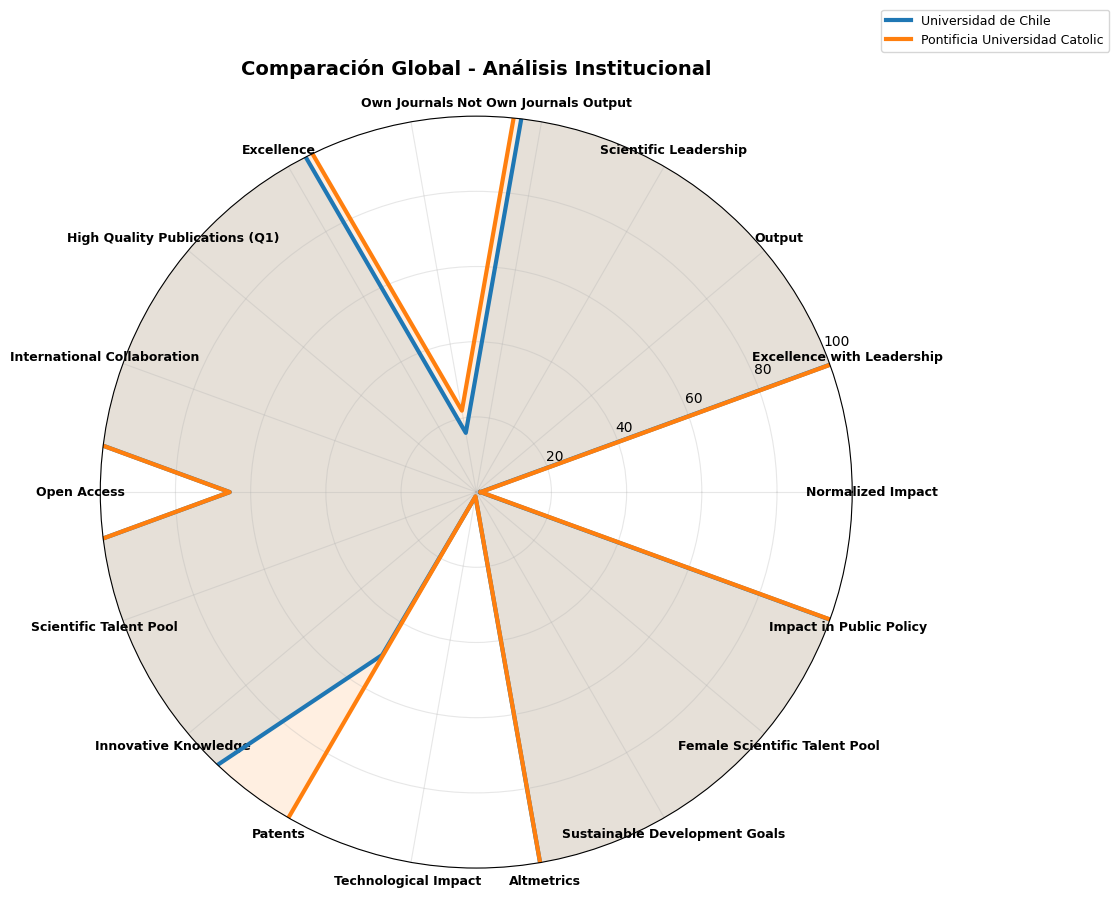


📊 PUNTAJES TOTALES - Datos: CON RANKING
────────────────────────────────────────────────────────────────────────────────
💡 NOTA: Usando valores pre-calculados de 'Puntuacion_Total'
🏫 Universidad de Chile (Referencia): 100.0
🟢 Pontificia Universidad Catolica de Chile: 91.9 → por DEBAJO por 8.1 puntos

🔍 VARIABLES INDIVIDUALES
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Variable                                          Universidad de Chile     Pontificia Universid
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Normalized Impact (13%)                                       1.1  🔴 ↓                      1.2
Excellence with Leadership (8%)                             819.0  🟢 ↑                    801.0
Output (8%)                                               18482.0  🟢 ↑                  16831.0
Scientific Leadership (5%)                    

KeyboardInterrupt: Interrupted by user

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ======================================================
# PESOS PERSONALIZADOS
# ======================================================

PESOS = {
    "normalized_impact": 0.13,
    "excel_lider": 0.08,
    "output": 0.08,
    "lider": 0.05,
    "not_own_journals_output": 0.03,
    "own_journals": 0.03,
    "excel": 0.02,
    "q1": 0.02,
    "colab": 0.02,
    "open_access": 0.02,
    "stp": 0.02,
    "ik": 0.10,
    "patents": 0.10,
    "tech_impact": 0.10,
    "AM": 0.03,
    "sdg": 0.05,
    "female_stp": 0.03,
    "overton": 0.03
}

NOMBRES = {
    "normalized_impact": "Normalized Impact",
    "excel_lider": "Excellence with Leadership",
    "output": "Output",
    "lider": "Scientific Leadership",
    "not_own_journals_output": "Not Own Journals Output",
    "own_journals": "Own Journals",
    "excel": "Excellence",
    "q1": "High Quality Publications (Q1)",
    "colab": "International Collaboration",
    "open_access": "Open Access",
    "stp": "Scientific Talent Pool",
    "ik": "Innovative Knowledge",
    "patents": "Patents",
    "tech_impact": "Technological Impact",
    "AM": "Altmetrics",
    "sdg": "Sustainable Development Goals",
    "female_stp": "Female Scientific Talent Pool",
    "overton": "Impact in Public Policy"
}

# ======================================================
# SELECCIÓN DE DATASET
# ======================================================

def seleccionar_dataset():
    """Pregunta al usuario qué dataset desea usar"""
    print("\n" + "="*80)
    print("📊 SELECCIÓN DE DATASET")
    print("="*80)
    print("\n¿Qué dataset deseas usar para el análisis?")
    print("1. DATOS NORMALIZADOS (0-100)")
    print("2. DATOS SIN NORMALIZAR")

    while True:
        try:
            opcion = input("\nSelecciona opción (1 o 2): ").strip()
            if opcion == "1":
                archivo = "instituciones_chilenas_limpias_con_ranking_y_AM_NORMALIZADO.csv"
                print(f"\n✅ Usando datos NORMALIZADOS: {archivo}")
                return archivo, "NORMALIZADOS"
            elif opcion == "2":
                archivo = "instituciones_chilenas_limpias_con_ranking_y_AM.csv"
                print(f"\n✅ Usando datos con RANKING: {archivo}")
                return archivo, "CON RANKING"
            else:
                print("❌ Opción inválida. Por favor selecciona 1 o 2.")
        except KeyboardInterrupt:
            print("\n\n👋 Operación cancelada por el usuario")
            return None, None

def cargar_dataset(archivo_seleccionado):
    """Carga el dataset seleccionado"""
    try:
        df = pd.read_csv(archivo_seleccionado)
        print(f"✅ Dataset cargado correctamente")
        print(f"📊 Total de instituciones: {len(df)}")

        # Verificar si existe la columna Puntuacion_Total
        if 'Puntuacion_Total' in df.columns:
            print(f"📈 Columna 'Puntuacion_Total' detectada - Usando scores pre-calculados")

            # Verificar si hay valores NaN en Puntuacion_Total
            nan_count = df['Puntuacion_Total'].isna().sum()
            if nan_count > 0:
                print(f"⚠️  Advertencia: {nan_count} instituciones tienen NaN en 'Puntuacion_Total'")
                print(f"   Para estas instituciones, se calculará el score manualmente")

                # Mostrar primeras instituciones con NaN
                nan_instituciones = df[df['Puntuacion_Total'].isna()]['Institucion'].head(3).tolist()
                for inst in nan_instituciones:
                    print(f"   • {inst}")
                if len(nan_instituciones) < nan_count:
                    print(f"   ... y {nan_count - len(nan_instituciones)} más")
        else:
            print(f"⚠️  Advertencia: No se encontró 'Puntuacion_Total' - Se calcularán scores automáticamente")

        # Verificar columnas de interés
        columnas_requeridas = list(PESOS.keys()) + ['Institucion']
        columnas_faltantes = [col for col in columnas_requeridas if col not in df.columns]

        if columnas_faltantes:
            print(f"⚠️  Advertencia: Faltan columnas: {columnas_faltantes[:3]}...")
            print(f"   Se usarán valores por defecto (0) para estas columnas")

        return df

    except FileNotFoundError:
        print(f"❌ Error: No se encontró el archivo '{archivo_seleccionado}'")
        print("💡 Asegúrate de que el archivo esté en la misma carpeta")
        return None
    except Exception as e:
        print(f"❌ Error al cargar el dataset: {e}")
        return None

# ======================================================
# FUNCIONES BASE
# ======================================================

def calcular_score(row, variable_extra=None, valor_extra=None):
    """Calcula score basado en los pesos personalizados o usa Puntuacion_Total si está disponible"""
    # Verificar si la columna Puntuacion_Total existe y no es NaN
    if "Puntuacion_Total" in row.index:
        total_score = pd.to_numeric(row.get("Puntuacion_Total"), errors='coerce')
        if not pd.isna(total_score) and total_score is not None:
            return float(total_score)
        else:
            # Si es NaN o None, calcular manualmente
            print(f"⚠️  Advertencia: Puntuacion_Total es NaN/None para {row.get('Institucion', 'institución')} - Calculando manualmente")

    # Calcular manualmente (backward compatibility o fallback)
    score = 0.0
    for col, peso in PESOS.items():
        valor = pd.to_numeric(row.get(col, 0), errors='coerce')
        if pd.isna(valor) or valor is None:
            valor = 0.0
        score += valor * peso
    return score

def radar(datos, nombres):
    """Genera gráfico radar para comparación visual"""
    vars_ = list(PESOS.keys())
    labels = [NOMBRES[v] for v in vars_]

    angles = np.linspace(0, 2*np.pi, len(vars_), endpoint=False).tolist()
    angles += angles[:1]

    plt.figure(figsize=(12, 9))
    ax = plt.subplot(111, polar=True)

    # Colores para las líneas
    colores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    for i, (d, n) in enumerate(zip(datos, nombres)):
        values = []
        for v in vars_:
            valor = pd.to_numeric(d.get(v, 0), errors='coerce')
            if pd.isna(valor) or valor is None:
                values.append(0.0)
            else:
                values.append(float(valor))
        values.append(values[0])  # Cerrar el polígono
        ax.plot(angles, values, linewidth=3, label=n[:30], color=colores[i % len(colores)])
        ax.fill(angles, values, alpha=0.12, color=colores[i % len(colores)])

    ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=9, fontweight='bold')
    ax.set_ylim(0, 100)
    ax.set_title("Comparación Global - Análisis Institucional", pad=30, fontsize=14, fontweight='bold')
    ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# ======================================================
# ANÁLISIS ESTRATÉGICO (ADAPTADO)
# ======================================================

def analisis_estrategico_avanzado(uni1_data, uni2_data, nombre_uni1, nombre_uni2):
    """
    Análisis que considera: impacto, dificultad y potencial real
    """

    # Definir dificultad de mejora por tipo de variable
    dificultad = {
        "normalized_impact": 0.8,        # Difícil - impacto normalizado toma tiempo
        "excel_lider": 0.9,              # Muy difícil - excelencia con liderazgo
        "output": 0.7,                   # Media-alta - producción científica
        "lider": 0.8,                    # Difícil - liderazgo científico
        "not_own_journals_output": 0.6,  # Media - publicaciones en revistas externas
        "own_journals": 0.5,             # Media - revistas propias
        "excel": 0.7,                    # Media-alta - excelencia
        "q1": 0.6,                       # Media - publicaciones Q1
        "colab": 0.4,                    # Media-baja - colaboración internacional
        "open_access": 0.3,              # Baja - acceso abierto
        "stp": 0.5,                      # Media - talento científico
        "ik": 0.7,                       # Media-alta - conocimiento innovador
        "patents": 0.8,                  # Difícil - patentes
        "tech_impact": 0.7,              # Media-alta - impacto tecnológico
        "AM": 0.3,                       # Baja - altmetrics
        "sdg": 0.4,                      # Media-baja - objetivos desarrollo sostenible
        "female_stp": 0.4,               # Media-baja - talento científico femenino
        "overton": 0.5                   # Media - impacto en políticas públicas
    }

    estrategias = []

    for col, peso in PESOS.items():
        # Convertir a numérico y manejar NaN
        valor_uni1 = pd.to_numeric(uni1_data.get(col, 0), errors='coerce')
        valor_uni2 = pd.to_numeric(uni2_data.get(col, 0), errors='coerce')

        if pd.isna(valor_uni1) or valor_uni1 is None:
            valor_uni1 = 0.0
        if pd.isna(valor_uni2) or valor_uni2 is None:
            valor_uni2 = 0.0

        diferencia = valor_uni2 - valor_uni1

        # Calcular mejora máxima realista (depende de la dificultad)
        mejora_maxima_realista = (100 - valor_uni1) * (1 - dificultad[col])
        mejora_optima = min(abs(diferencia), mejora_maxima_realista) if diferencia > 0 else mejora_maxima_realista * 0.5

        impacto = mejora_optima * peso
        eficiencia = impacto / (dificultad[col] + 0.1)  # +0.1 para evitar división por 0

        if diferencia > 0:  # Vamos detrás
            estrategias.append((col, diferencia, impacto, eficiencia, "RECUPERAR", mejora_optima))
        else:  # Vamos adelante
            estrategias.append((col, abs(diferencia), impacto, eficiencia, "CONSOLIDAR", mejora_optima))

    # Ordenar por eficiencia (impacto/dificultad)
    estrategias.sort(key=lambda x: x[3], reverse=True)

    print(f"\n🎯 RUTA ESTRATÉGICA ÓPTIMA PARA {nombre_uni1}")
    print("=" * 100)
    print("┌──────────────────────────────────┬──────────┬──────────┬──────────┬────────────┬──────────┐")
    print(f"│ {'Variable':<32} │ {'Brecha':>8} │ {'Impacto':>8} │ {'Eff':>6} │ {'Acción':<10} │ {'Meta':>8} │")
    print("├──────────────────────────────────┼──────────┼──────────┼──────────┼────────────┼──────────┤")

    for col, brecha, impacto, eff, accion, meta in estrategias[:]:
        nombre_completo = NOMBRES.get(col, col)
        if len(nombre_completo) > 32:
            nombre_completo = nombre_completo[:29] + "..."

        print(f"│ {nombre_completo:<32} │ {brecha:>8.1f} │ {impacto:>8.3f} │ {eff:>6.1f} │ {accion:<10} │ {meta:>7.1f} │")

    print("└──────────────────────────────────┴──────────┴──────────┴──────────┴────────────┴──────────┘")

    # Recomendación principal
    if estrategias:
        mejor_opcion = estrategias[0]
        nombre_mejor_opcion = NOMBRES.get(mejor_opcion[0], mejor_opcion[0])

        print(f"\n💡 RECOMENDACIÓN PRINCIPAL: Enfócate en {nombre_mejor_opcion}")
        print(f"   📊 Justificación:")
        print(f"   - Eficiencia: {mejor_opcion[3]:.1f} (impacto vs dificultad)")
        print(f"   - Meta realista: +{mejor_opcion[5]:.1f} puntos")
        print(f"   - Impacto en ranking: +{mejor_opcion[2]:.3f} puntos")

        # Análisis de escenarios
        print(f"\n📈 ESCENARIOS ESTRATÉGICOS:")

        # Escenario conservador (top 3 más eficientes)
        impacto_total = sum(estrategia[2] for estrategia in estrategias[:3])
        print(f"   🟢 ESCENARIO CONSERVADOR (1 año):")
        print(f"      Invertir en top 3 variables más eficientes")
        print(f"      Ganancia estimada: +{impacto_total:.2f} puntos")

        # Escenario agresivo (top 6)
        print(f"   🟡 ESCENARIO AGRESIVO (2-3 años):")
        impacto_total_agresivo = sum(estrategia[2] for estrategia in estrategias[:6])
        print(f"      Inversión integral en 6 variables clave")
        print(f"      Ganancia estimada: +{impacto_total_agresivo:.2f} puntos")

        # Puntos necesarios para superar
        try:
            score_actual_uni1 = calcular_score(uni1_data)
            score_actual_uni2 = calcular_score(uni2_data)
            puntos_para_superar = score_actual_uni2 - score_actual_uni1

            if puntos_para_superar > 0:
                print(f"\n🎯 OBJETIVO: Superar a {nombre_uni2}")
                print(f"   - Necesitas: +{puntos_para_superar:.2f} puntos")
                print(f"   - Con escenario conservador: {'✅ POSIBLE' if impacto_total >= puntos_para_superar else '⚠️  PARCIAL'}")
                print(f"   - Con escenario agresivo: {'✅ GARANTIZADO' if impacto_total_agresivo >= puntos_para_superar else '✅ POSIBLE'}")
        except Exception as e:
            print(f"\n⚠️  No se pudo calcular el objetivo: {e}")

# ======================================================
# COMPARADOR PRINCIPAL (ADAPTADO)
# ======================================================

def comparar(df, indices, simular=False, tipo_datos="NORMALIZADOS"):
    """Función principal de comparación"""
    datos = [df.iloc[i].copy() for i in indices]
    nombres = [d['Institucion'] for d in datos]

    # Mostrar gráfico radar si hay 2-4 universidades
    if 2 <= len(datos) <= 4:
        print(f"\n📊 GENERANDO GRÁFICO RADAR DE COMPARACIÓN (Datos: {tipo_datos})...")
        radar(datos, nombres)

    # Calcular scores con manejo de errores
    scores = []
    for d in datos:
        try:
            score = calcular_score(d)
            scores.append(score)
        except Exception as e:
            print(f"❌ Error calculando score para {d.get('Institucion', 'institución')}: {e}")
            scores.append(0.0)

    print(f"\n📊 PUNTAJES TOTALES - Datos: {tipo_datos}")
    print("─" * 80)

    # Verificar si estamos usando Puntuacion_Total
    if "Puntuacion_Total" in df.columns:
        print("💡 NOTA: Usando valores pre-calculados de 'Puntuacion_Total'")

    # Mostrar primer score con formato seguro
    if scores:
        print(f"🏫 {nombres[0]} (Referencia): {scores[0]:.1f}")

        # Mostrar comparaciones
        for i in range(1, len(scores)):
            if scores[0] is not None and scores[i] is not None:
                brecha = scores[i] - scores[0]
                icon = "🔴" if brecha > 0 else "🟢" if brecha < 0 else "⚪"
                estado = "por ENCIMA" if brecha > 0 else "por DEBAJO" if brecha < 0 else "EMPATA"
                print(f"{icon} {nombres[i]}: {scores[i]:.1f} → {estado} por {abs(brecha):.1f} puntos")
            else:
                print(f"❌ {nombres[i]}: Error en cálculo de score")

    # ==================================================
    # TABLA VARIABLES DETALLADA
    # ==================================================

    print("\n🔍 VARIABLES INDIVIDUALES")
    print("─" * 120)

    # Encabezado
    header = f"{'Variable':45}"
    for n in nombres:
        header += f"{n[:20]:>25}"
    print(header)
    print("─" * 120)

    for v, peso in PESOS.items():
        fila = f"{NOMBRES[v]} ({peso*100:.0f}%)".ljust(45)

        if len(datos) == 2:
            v1 = pd.to_numeric(datos[0].get(v, 0), errors='coerce')
            v2 = pd.to_numeric(datos[1].get(v, 0), errors='coerce')
            if pd.isna(v1): v1 = 0
            if pd.isna(v2): v2 = 0

            if v1 > v2:
                emoji = "🟢 ↑"
            elif v1 < v2:
                emoji = "🔴 ↓"
            else:
                emoji = "⚪ ="
            fila += f"{v1:>20.1f} {emoji:>4}{v2:>25.1f}"
        else:
            for d in datos:
                valor = pd.to_numeric(d.get(v, 0), errors='coerce')
                if pd.isna(valor): valor = 0
                fila += f"{valor:>25.1f}"

        print(fila)

    # ==================================================
    # SIMULACIÓN
    # ==================================================

    if simular and len(datos) >= 1:
        print("\n🔄 SIMULACIÓN DE MEJORA")
        vars_list = list(PESOS.keys())

        for i, v in enumerate(vars_list, 1):
            print(f"{i:2d}. {NOMBRES[v]}")

        try:
            idx = int(input("\nSelecciona variable a mejorar (número): ")) - 1
            if 0 <= idx < len(vars_list):
                var = vars_list[idx]
                pct = float(input("Porcentaje de mejora (ej: 10 para 10%): "))

                base = pd.to_numeric(datos[0].get(var, 0), errors='coerce')
                if pd.isna(base): base = 0

                nuevo_valor = min(base * (1 + pct / 100), 100)
                datos[0][var] = nuevo_valor

                nuevo_score = calcular_score(datos[0])

                print(f"\n📈 RESULTADO DE LA SIMULACIÓN")
                print(f"• Variable mejorada: {NOMBRES[var]}")
                print(f"• Valor original: {base:.1f}")
                print(f"• Valor simulado: {nuevo_valor:.1f} (+{pct}%)")
                print(f"• Score original: {scores[0]:.2f}")
                print(f"• Score simulado: {nuevo_score:.2f}")
                print(f"• Ganancia total: +{nuevo_score - scores[0]:.2f} puntos")

                if len(datos) == 2:
                    nueva_brecha = scores[1] - nuevo_score
                    if nuevo_score > scores[1] and scores[0] <= scores[1]:
                        print(f"• 🎉 ¡CAMBIO DE POSICIÓN! Ahora supera a {nombres[1]}")
                    elif nuevo_score > scores[1]:
                        print(f"• 📈 Amplía su ventaja sobre {nombres[1]}")
                    else:
                        print(f"• ⚠️  Sigue por debajo de {nombres[1]}")
                        print(f"• 💡 Necesita {abs(nueva_brecha):.2f} puntos más para superarla")
            else:
                print("❌ Número fuera de rango")
        except (ValueError, IndexError):
            print("❌ Opción inválida")

    # ==================================================
    # ANÁLISIS ESTRATÉGICO (solo para 2 instituciones)
    # ==================================================

    if len(datos) == 2:
        analisis_estrategico_avanzado(datos[0], datos[1], nombres[0], nombres[1])

    # ==================================================
    # EXPLICACIONES FINALES
    # ==================================================

    print("\n📘 LEYENDA Y EXPLICACIONES")
    print("─" * 60)
    print("• 🟢 Verde: la institución de referencia está mejor posicionada")
    print("• 🔴 Rojo: la institución de referencia está peor posicionada")
    print("• ↑/↓: indica dirección de la ventaja")
    print("• Brecha: diferencia en puntaje total respecto a la referencia")
    print("• Impacto: mejora potencial × peso en el cálculo")
    print("• Eff (Eficiencia): impacto ajustado por dificultad de mejora")
    print("• Meta: incremento máximo realista considerando restricciones")

# ======================================================
# INTERFAZ INTERACTIVA (ADAPTADA)
# ======================================================

def comparador_interactivo():
    """Versión interactiva para comparar cualquier par de instituciones"""
    # Seleccionar dataset primero
    archivo_seleccionado, tipo_datos = seleccionar_dataset()
    if not archivo_seleccionado:
        return

    # Cargar dataset
    df = cargar_dataset(archivo_seleccionado)
    if df is None:
        return

    while True:
        print("\n" + "="*80)
        print(f"🏫 COMPARADOR INTERACTIVO DE INSTITUCIONES CHILENAS")
        print(f"📊 Datos: {tipo_datos}")
        print("="*80)

        print("\n📋 INSTITUCIONES DISPONIBLES:")
        for i, nombre in enumerate(df['Institucion'], 1):
            print(f"   {i:2d}. {nombre}")

        print("\n🔍 Selecciona instituciones a comparar:")
        print("   Ejemplo: '1,3' para comparar institución 1 con 3")
        print("           '1,2,4' para comparar 3 instituciones")
        print("           'salir' para terminar")

        sel = input("\nSelección: ").strip()

        if sel.lower() == 'salir':
            break

        try:
            indices = [int(x.strip()) - 1 for x in sel.split(",")]

            # Validar índices
            if any(idx < 0 or idx >= len(df) for idx in indices):
                print("❌ Uno o más índices están fuera de rango")
                continue

            if len(indices) < 1:
                print("❌ Debes seleccionar al menos una institución")
                continue

            if len(indices) > 4:
                print("⚠️  Advertencia: Para mejores resultados, compara máximo 4 instituciones")

            # Preguntar por simulación solo si hay al menos 1 institución
            sim = False
            if len(indices) >= 1:
                sim_input = input("¿Deseas simular una mejora en la primera institución? (s/n): ").lower()
                sim = sim_input == "s"

            # Ejecutar comparación
            comparar(df, indices, sim, tipo_datos)

            # Preguntar si continuar
            continuar = input("\n¿Quieres hacer otra comparación? (s/n): ").strip().lower()
            if continuar != 's':
                print(f"\n💾 Dataset actual: {tipo_datos}")
                print("¿Deseas cambiar de dataset para la próxima comparación? (s/n)")
                cambiar = input().strip().lower()
                if cambiar == 's':
                    archivo_seleccionado, tipo_datos = seleccionar_dataset()
                    if archivo_seleccionado:
                        df = cargar_dataset(archivo_seleccionado)
                        if df is None:
                            return

        except ValueError:
            print("❌ Formato inválido. Usa números separados por comas")
        except Exception as e:
            print(f"❌ Error: {e}")

# ======================================================
# EJECUCIÓN PRINCIPAL
# ======================================================

if __name__ == "__main__":
    print("🚀 INICIANDO COMPARADOR AVANZADO DE INSTITUCIONES CHILENAS")
    print("="*80)
    print("💡 Características:")
    print("   • Selección entre datasets normalizados y con ranking")
    print("   • Gráficos radar para visualización comparativa")
    print("   • Análisis estratégico con recomendaciones específicas")
    print("   • Simulación de mejoras con impacto estimado")
    print("   • Comparación de 2 a 4 instituciones simultáneamente")
    print("="*80)

    comparador_interactivo()